# 期末综合练习（1）

### 设计一个CNN网络，训练自定义图像数据集的分类操作。 通过优化网络结构与超参数、正则化、数据增强等各种手段，尽可能提高准确率。
Dataset Context：<BR>
This is image data of Natural Scenes around the world.<BR>
Dataset Content：<BR>
This Data contains around 25k images of size about 96x96 distributed under 6 categories.<BR>
{'buildings' -> 0, 'forest' -> 1, 'glacier' -> 2,
'mountain' -> 3,  'sea' -> 4, 'street' -> 5 }
<BR>
    
#### 须自建模型，形式不限，不能使用预定义模型、预训练模型、不能完整抄袭ImageNet模型，要求：
1)展示训练过程，显示loss曲线和accuracy曲线。利用callback将最佳模型保存到文件<BR>
(注意：在"save"目录下建立以自己学号命名的子目录，然后在该子目录下保存文件)。<BR>
2)读取最佳模型进行指标评估并显示结果，展示混淆矩阵。<BR>
3)根据混淆矩阵找出误判率最高的两种情形，展示错误分类图片，分析原因。<BR>
4)展示典型图片（正确分类与错误分类）的热力图，评估分类的可解释性。<BR>

    
#### 考核要点：
1）上述要求功能程序实现的完成度、完整度，结果展示的可读性<BR>
2）score = model.evaluate(testset)<BR>
计算得到的准确率指标。请调整模型努力提高指标（0.8以上）！成绩将根据准确率指标[0.8 - 0.9]打分<BR>

In [ ]:
import os
folder = 'data/project/seg_test/seg_test/sea'

if not os.path.exists(folder):
    print("错误：文件夹不存在，请检查路径")
else:
    contents = os.listdir(folder)
    print(f"文件夹 {folder} 中包含 {len(contents)} 个文件/文件夹:")
    for item in contents:
        print("  -", item)

In [ ]:
import os
from IPython.display import FileLink, display

# 注意文件名开头有空格，路径中也有空格，使用原始字符串或直接写即可
file_path = 'data/project/seg_test/seg_test/sea/23213.jpg'

if os.path.exists(file_path):
    display(FileLink(file_path, result_html_prefix="点击下载图片: "))
else:
    print(f"文件不存在：{file_path}")

In [1]:
#首先执行GPU资源分配代码，勿删除。
import GPU
GPU.show()

Thu Jun  4 13:48:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.142                Driver Version: 580.142        CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:02:00.0 Off |                  N/A |
| 51%   52C    P2            134W /  350W |    7024MiB /  24576MiB |     13%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#选择一个空闲GPU，#0  #1  #2  不要超过4096，超过会杀进程！
GPU.alloc(0,2048)

Success.


## 1、导入包

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import cv2
from tensorflow.keras import regularizers

## 2、个人目录

In [4]:
# 学号
my_id = '3230105908'
save_dir = os.path.join('save', my_id)
os.makedirs(save_dir, exist_ok=True)

# 数据路径
train_path = 'data/project/seg_train/seg_train'
test_path = 'data/project/seg_test/seg_test'

## 3、数据预处理

In [5]:
IMG_SIZE = 128
BATCH_SIZE = 64

# 数据增强
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
test_datagen = ImageDataGenerator(rescale=1./255)

trainset = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
testset = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [6]:
print(trainset.class_indices)
class_names = list(trainset.class_indices.keys())
print(class_names)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 4、构建CNN模型

In [7]:
from tensorflow.keras import models, layers

In [8]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
#     # Block 1
#     layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2,2)),
#     layers.Dropout(0.3),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),
    
#     # Block 4
#     layers.Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2,2)),
#     layers.Dropout(0.3),

    # 分类头
    layers.GlobalAveragePooling2D(),
#     layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 64)      1792      
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 64)     256       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 128, 128, 64)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 64)      36928     
                                                                 
 batch_normalization_1 (Batc  (None, 128, 128, 64)     256       
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 128, 128, 64)      0

In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 5、训练模型

Epoch 1/50
220/220 [==============================] - ETA: 0s - loss: 1.5275 - accuracy: 0.4346
Epoch 1: val_loss improved from inf to 1.47444, saving model to save/3230105908/best_model.keras
220/220 [==============================] - 64s 282ms/step - loss: 1.5275 - accuracy: 0.4346 - val_loss: 1.4744 - val_accuracy: 0.4610
Epoch 2/50
220/220 [==============================] - ETA: 0s - loss: 1.1784 - accuracy: 0.5668
Epoch 2: val_loss improved from 1.47444 to 1.09282, saving model to save/3230105908/best_model.keras
220/220 [==============================] - 63s 288ms/step - loss: 1.1784 - accuracy: 0.5668 - val_loss: 1.0928 - val_accuracy: 0.6123
Epoch 3/50
220/220 [==============================] - ETA: 0s - loss: 1.0468 - accuracy: 0.6205
Epoch 3: val_loss improved from 1.09282 to 1.05846, saving model to save/3230105908/best_model.keras
220/220 [==============================] - 63s 288ms/step - loss: 1.0468 - accuracy: 0.6205 - val_loss: 1.0585 - val_accuracy: 0.6047
Epoch 4/50


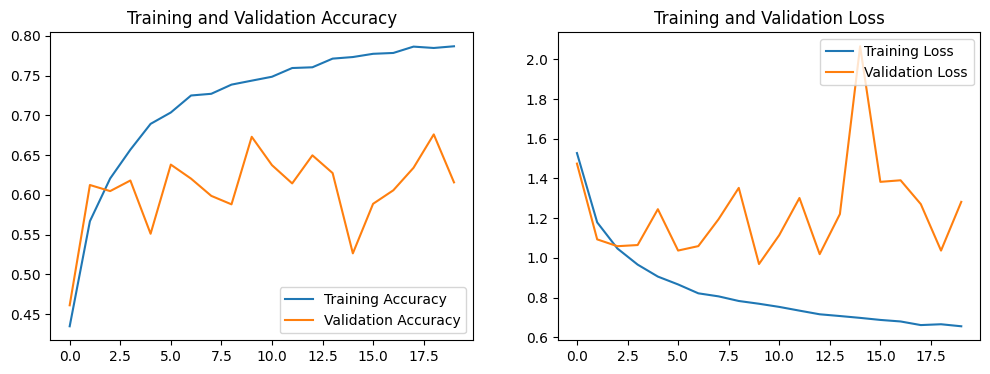

In [10]:
# 回调列表
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=False),
    ModelCheckpoint(
        filepath=os.path.join(save_dir, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

epochs = 50   

history = model.fit(
    trainset,
    validation_data=testset,
    epochs=epochs,
    callbacks=callbacks
)

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)